# Anomaly detection

Supervised classifiers are trained to recognise the fraud patterns present in the labelled training data. They cannot, by construction, recognise patterns the labels do not contain. Anomaly detection methods are designed for the opposite case: they learn what *legitimate* activity looks like and flag deviations, without using fraud labels at training time.

For a real risk scoring framework, both paradigms are useful. The supervised model captures known fraud efficiently; the anomaly detector raises the new and the unusual. We evaluate six anomaly detection methods, drawn from the four conceptual families that dominate the field:

- **Isolation-based** — Isolation Forest. Anomalies are easy to isolate by random partitioning.
- **Distribution-based** — ECOD and COPOD. Anomalies have low probability under the empirical distribution of legitimate activity.
- **Boundary-based** — One-Class SVM. Anomalies fall outside a tight enclosing surface around legitimate activity.
- **Density-based** — Local Outlier Factor. Anomalies have lower local density than their neighbours.
- **Reconstruction-based** — Autoencoder. Anomalies cannot be reconstructed accurately from a learned compressed representation.

This breadth is deliberate. Different fraud patterns surface under different anomaly definitions, and evaluating across the four families is what distinguishes a methodological comparison from a single-method demonstration. We measure detection performance with PR-AUC and ROC-AUC, and we measure operational viability with wall-clock training/inference time and peak memory both matter when judging whether a method could be deployed.


In [ ]:
from contextlib import contextmanager
from pathlib import Path
import time
import tracemalloc
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from pyod.models.copod import COPOD
from pyod.models.ecod import ECOD
from pyod.models.iforest import IForest
from pyod.models.lof import LOF
from pyod.models.ocsvm import OCSVM
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from tensorflow.keras import layers, models

warnings.filterwarnings("ignore", category=UserWarning)

PROCESSED_DIR = Path("..") / "data" / "processed"
MODELS_DIR = Path("..") / "src" / "models"
FIGURES_DIR = Path("..") / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")


In [2]:
train = pd.read_csv(PROCESSED_DIR / "train.csv")
test = pd.read_csv(PROCESSED_DIR / "test.csv")

X_train = train.drop(columns=["isFraud"])
y_train = train["isFraud"]
X_test = test.drop(columns=["isFraud"])
y_test = test["isFraud"]

print(f"Train: {X_train.shape}, fraud rate {y_train.mean():.4%}")
print(f"Test:  {X_test.shape}, fraud rate {y_test.mean():.4%}")

Train: (5090096, 11), fraud rate 0.1291%
Test:  (1272524, 11), fraud rate 0.1291%


## 1. Semi-supervised setup

All six methods are fit on the *legitimate-only* slice of the training data. The model learns the shape of normal activity without being told that fraud exists, and is then asked to score everything in the test set. Fraud labels touch the pipeline only at evaluation time.

This is what makes the comparison meaningful. A detector that has seen fraud during training is no longer doing anomaly detection — it is doing supervised classification with a renamed loss function. The thesis question is whether unsupervised methods can match supervised ones on PaySim despite this label-free constraint, and the only way to answer it is to enforce the constraint cleanly.

In [3]:
X_train_legit = X_train[y_train == 0]
print(f"Legitimate training rows: {len(X_train_legit):,}")

Legitimate training rows: 5,083,526


## 2. Subsampling strategy

Three of the six methods (One-Class SVM, LOF, autoencoder validation) are computationally bounded and require subsampling to remain tractable on this dataset. We adopt a fixed subsample size of 50,000 legitimate transactions, which is the standard scale used in the published anomaly-detection literature for benchmarking distance- and kernel-based methods at scale (see PyOD's own benchmark paper, Zhao et al. 2024).

Subsampling introduces variance: the specific 50,000 rows chosen affect the resulting model. The principled response is to repeat the fit several times with different seeds and report the mean and standard deviation. We do this for OCSVM and LOF below.

The remaining methods (Isolation Forest, ECOD, COPOD, autoencoder training) scale to the full ~5M legitimate training rows without difficulty. We use the full data for those, so the comparison reflects the strongest version of each method.


In [4]:
SUBSAMPLE_SIZE = 50_000
N_REPEATS = 3  # repetitions for variance estimation on subsampled methods

def stratified_subsample(X: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    """Draw a random subsample of size ``n`` from ``X``.

    A simple uniform random sample is sufficient here because the input is
    already filtered to legitimate transactions only — there is no class to
    stratify on. The function is named for clarity in case the input
    constraint changes.

    Parameters
    ----------
    X : DataFrame
        Population to draw from.
    n : int
        Sample size; if ``n`` exceeds ``len(X)``, returns the whole frame.
    seed : int
        Seed for reproducibility.

    Returns
    -------
    DataFrame
        Subsampled rows with the original index preserved.
    """
    if n >= len(X):
        return X
    return X.sample(n=n, random_state=seed)


## 3. Profiling utility

For each method we record wall-clock time and peak Python memory during fitting, and wall-clock time during scoring. These numbers are not the primary thesis result — PR-AUC is — but they are required to judge whether a method could be deployed at the scale of a real fraud system. A model that achieves PR-AUC 0.90 in three seconds is operationally different from one that achieves PR-AUC 0.92 in three hours.

The context manager below uses `time.perf_counter` for wall time (the right clock for elapsed time, not CPU time) and `tracemalloc` for peak Python memory. `tracemalloc` measures Python objects only; it does not capture memory allocated inside C extensions like XGBoost or TensorFlow, so the memory numbers should be read as a lower bound for those methods. Wall time is captured accurately for all methods.


In [5]:
@contextmanager
def profile(record: dict, key: str):
    """Capture wall-clock time and peak memory for the enclosed block.

    Results are stored under ``record[key]`` so that multiple measurements
    accumulate naturally during the notebook run.

    Parameters
    ----------
    record : dict
        Mutable dictionary collecting profiling results across the notebook.
    key : str
        Identifier for the measurement, e.g. ``"iforest_fit"``.

    Notes
    -----
    Memory measurement uses ``tracemalloc``, which tracks Python-level
    allocations only. Methods that do most of their work inside C
    extensions (xgboost, tensorflow) will report lower peak memory than
    they actually use. Wall-clock time is unaffected by this caveat.
    """
    tracemalloc.start()
    t0 = time.perf_counter()
    try:
        yield
    finally:
        elapsed = time.perf_counter() - t0
        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        record[key] = {"wall_seconds": elapsed, "peak_mb": peak / 1e6}


# Single shared dictionary — every method appends to this and we summarise
# at the end of the notebook.
profile_results: dict = {}


## 4. Isolation Forest (isolation-based)

**Theoretical motivation.** Isolation Forest builds an ensemble of random binary trees on subsamples of the data. Each tree partitions the feature space at random until every point is isolated in its own leaf. Anomalies — points in low-density regions — require fewer splits to isolate, so the *path length* from root to leaf serves as the anomaly score: short paths mean anomalous, long paths mean normal.

The original paper (Liu, Ting, Zhou, 2008) shows that anomalies are isolated *on average* in O(log n) splits, and that the algorithm needs only small subsamples per tree (the canonical choice is 256 rows) for the path-length statistic to converge. This is what makes it scalable: it does not need to see the whole dataset to produce a reliable score.

**Complexity.**
- Training: O(t · ψ · log ψ), where t = number of trees and ψ = subsample size.
- Scoring: O(t · log ψ) per row.

Both are independent of the training set size n, which is why we can fit on the full ~5M legitimate rows without subsampling.


In [8]:
iforest = IForest(
    n_estimators=200,
    max_samples=256,        # the original paper's recommendation
    contamination=0.001,   # only used for the predict() shortcut, which we ignore
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

with profile(profile_results, "iforest_fit"):
    iforest.fit(X_train_legit)

with profile(profile_results, "iforest_score"):
    iforest_scores = iforest.decision_function(X_test)

# pyod's decision_function returns the anomaly score directly — higher
# means more anomalous. This matches the convention used elsewhere in the
# project, no sign flip required.
print(f"IForest PR-AUC: {average_precision_score(y_test, iforest_scores):.4f}")
print(f"IForest ROC-AUC: {roc_auc_score(y_test, iforest_scores):.4f}")

IForest PR-AUC: 0.0189
IForest ROC-AUC: 0.9643


## 5. ECOD (distribution-based)

**Theoretical motivation.** ECOD (Empirical Cumulative Distribution-based Outlier Detection, Li et al. 2022) treats anomaly detection as a tail-probability estimation problem. For each feature it estimates two empirical CDFs, one from below, one from above, and aggregates the per-feature tail probabilities into a single anomaly score under an assumption of feature independence.

The independence assumption is wrong in any realistic dataset, but the method works in practice because the *direction* of the dependency rarely flips the ordering of points by tail extremity. ECOD's main practical advantage over Isolation Forest is that it has zero hyperparameters and zero randomness, the same data always produces the same scores.

**Complexity.** O(n · d) for both training and scoring, where d is the number of features. This is linear in n and trivially parallelisable, which makes ECOD the most scalable method in the comparison.

The PyOD benchmark paper reports that ECOD outperforms 11 competing methods on average across 30 datasets. This makes it the right choice as the "no-tuning baseline" for a methodological comparison.


In [7]:
ecod = ECOD(n_jobs=-1)

with profile(profile_results, "ecod_fit"):
    ecod.fit(X_train_legit)

with profile(profile_results, "ecod_score"):
    ecod_scores = ecod.decision_function(X_test)

print(f"ECOD PR-AUC: {average_precision_score(y_test, ecod_scores):.4f}")
print(f"ECOD ROC-AUC: {roc_auc_score(y_test, ecod_scores):.4f}")


[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done   2 out of  11 | elapsed:    8.3s remaining:   37.9s
[Parallel(n_jobs=11)]: Done  11 out of  11 | elapsed:   10.9s finished
[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done   2 out of  11 | elapsed:    4.4s remaining:   20.2s
[Parallel(n_jobs=11)]: Done  11 out of  11 | elapsed:    9.5s finished


ECOD PR-AUC: 0.0035
ECOD ROC-AUC: 0.8097


## 6. COPOD (distribution-based)

**Theoretical motivation.** COPOD (Copula-based Outlier Detection, Li et al. 2020) is closely related to ECOD but uses the copula construction explicitly. It transforms each feature to its empirical CDF rank, fits the joint distribution of the rank-transformed data using the empirical copula, and scores anomalies as points with low joint probability.

In practice ECOD and COPOD often perform similarly. We include both because they encode slightly different assumptions about how features combine, and the comparison reveals whether feature-interaction structure matters for fraud detection on this dataset. If COPOD substantially outperforms ECOD, the joint-distribution information matters; if they are equivalent, the marginals carry the signal.

**Complexity.** Same asymptotic complexity as ECOD: O(n · d). Parameter-free.


In [9]:
copod = COPOD(n_jobs=-1)

with profile(profile_results, "copod_fit"):
    copod.fit(X_train_legit)

with profile(profile_results, "copod_score"):
    copod_scores = copod.decision_function(X_test)

print(f"COPOD PR-AUC: {average_precision_score(y_test, copod_scores):.4f}")
print(f"COPOD ROC-AUC: {roc_auc_score(y_test, copod_scores):.4f}")


[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done   2 out of  11 | elapsed:    3.2s remaining:   14.8s
[Parallel(n_jobs=11)]: Done  11 out of  11 | elapsed:    6.2s finished
[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done   2 out of  11 | elapsed:    5.9s remaining:   26.9s
[Parallel(n_jobs=11)]: Done  11 out of  11 | elapsed:    8.9s finished


COPOD PR-AUC: 0.0043
COPOD ROC-AUC: 0.8392


## 7. One-Class SVM (boundary-based)

**Theoretical motivation.** OCSVM (Schölkopf et al. 2001) learns a decision boundary that encloses the bulk of the training data while leaving a controlled fraction (`nu`) of points outside as "noise". At test time, points falling outside this boundary are flagged as anomalies. With an RBF kernel the boundary is non-linear in the input space but linear in the kernel-induced feature space.

**Complexity.** Training is O(n²) to O(n³) in the number of training rows, depending on the problem. This is the binding constraint: fitting OCSVM on the full ~5M legitimate training rows is infeasible. We subsample to 50,000 rows, fit the model, and score the full 1.27M-row test set. We repeat the fit with `N_REPEATS` different seeds to quantify the variance that subsampling introduces.

The standard benchmark choice for `nu` (the upper bound on the fraction of training points labelled as outliers, and a lower bound on the support vectors) is the assumed contamination rate. PaySim's training fraud rate is 0.13%, so `nu = 0.001` is the data-driven setting; we use `nu = 0.01` as a slightly more conservative choice that gives the model some flexibility.

In [10]:
ocsvm_pr_aucs = []
ocsvm_roc_aucs = []
ocsvm_scores_runs = []

for repeat in range(N_REPEATS):
    seed = RANDOM_STATE + repeat
    X_sub = stratified_subsample(X_train_legit, SUBSAMPLE_SIZE, seed=seed)

    ocsvm = OCSVM(kernel="rbf", gamma="scale", nu=0.01)

    with profile(profile_results, f"ocsvm_fit_run{repeat}"):
        ocsvm.fit(X_sub)

    with profile(profile_results, f"ocsvm_score_run{repeat}"):
        scores = ocsvm.decision_function(X_test)

    ocsvm_pr_aucs.append(average_precision_score(y_test, scores))
    ocsvm_roc_aucs.append(roc_auc_score(y_test, scores))
    ocsvm_scores_runs.append(scores)

# Average the scores across runs to obtain a single per-row anomaly score
# for the comparison plots and the risk-scoring framework.
ocsvm_scores = np.mean(ocsvm_scores_runs, axis=0)

print(f"OCSVM PR-AUC:  {np.mean(ocsvm_pr_aucs):.4f} ± {np.std(ocsvm_pr_aucs):.4f}")
print(f"OCSVM ROC-AUC: {np.mean(ocsvm_roc_aucs):.4f} ± {np.std(ocsvm_roc_aucs):.4f}")

OCSVM PR-AUC:  0.0306 ± 0.0007
OCSVM ROC-AUC: 0.9331 ± 0.0073


## 8. Local Outlier Factor (density-based)

**Theoretical motivation.** LOF (Breunig et al. 2000) compares the local density around each point to the local densities of its k nearest neighbours. A point with substantially lower density than its neighbours is flagged as anomalous. The "local" qualifier matters: LOF can detect outliers in regions that are themselves dense, which global density methods cannot.

**Complexity.** O(n · k · d) at fit time and O(n_test · n_train · d) at scoring time using exact KNN. With `n_train ≈ 50k` and `n_test ≈ 1.27M` this is at the edge of tractability on a single machine. We use `novelty=True` to separate fit from score (the default scikit-learn LOF requires re-fitting on the test set, which is methodologically wrong here), and PyOD's implementation uses BallTree for efficient nearest-neighbour search.

Like OCSVM, we subsample the training data to 50,000 rows and report variance over `N_REPEATS` seeds.


In [11]:
lof_pr_aucs = []
lof_roc_aucs = []
lof_scores_runs = []

for repeat in range(N_REPEATS):
    seed = RANDOM_STATE + repeat
    X_sub = stratified_subsample(X_train_legit, SUBSAMPLE_SIZE, seed=seed)

    lof = LOF(n_neighbors=20, n_jobs=-1, novelty=True)

    with profile(profile_results, f"lof_fit_run{repeat}"):
        lof.fit(X_sub)

    with profile(profile_results, f"lof_score_run{repeat}"):
        scores = lof.decision_function(X_test)

    lof_pr_aucs.append(average_precision_score(y_test, scores))
    lof_roc_aucs.append(roc_auc_score(y_test, scores))
    lof_scores_runs.append(scores)

lof_scores = np.mean(lof_scores_runs, axis=0)

print(f"LOF PR-AUC:  {np.mean(lof_pr_aucs):.4f} ± {np.std(lof_pr_aucs):.4f}")
print(f"LOF ROC-AUC: {np.mean(lof_roc_aucs):.4f} ± {np.std(lof_roc_aucs):.4f}")

LOF PR-AUC:  0.0178 ± 0.0015
LOF ROC-AUC: 0.8846 ± 0.0012


## 9. Autoencoder (reconstruction-based)

**Theoretical motivation.** An autoencoder is a neural network trained to copy its input to its output through a bottleneck layer of lower dimension than the input. When trained on legitimate transactions only, it learns a compressed representation of the manifold of normal activity. At test time, transactions that don't fit the learned manifold reconstruct poorly, and the per-row mean squared reconstruction error becomes the anomaly score.

The architecture is deliberately small (input → 16 → 8 → 16 → input). With only 11 input features, a deeper network would mostly memorise. The bottleneck of 8 dimensions is small enough to force genuine compression.

**Threshold setting.** If a hard decision threshold is needed (we don't use one for PR-AUC, which is continuous), it should be set on a held-out *validation* slice of legitimate training data — the percentile of reconstruction errors observed on legitimate data is a defensible threshold. Setting it on the test set's own MSE distribution is the threshold-leakage bug that the original notebook contained; we avoid it here by using the training-validation split that Keras handles internally.

**Complexity.** Training is O(epochs · n · d · h) where h is the network width; effectively linear in the data size for a fixed architecture. Inference is O(n · d · h), one forward pass per row. The autoencoder is the only method in the comparison whose runtime grows linearly with model complexity rather than with data dependencies, so it scales well.


In [12]:
input_dim = X_train_legit.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8,  activation="relu"),   # bottleneck
    layers.Dense(16, activation="relu"),
    layers.Dense(input_dim, activation="linear"),
])
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           187 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 659 (2.57 KB)

 Trainable params: 659 (2.57 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
    ),
    ModelCheckpoint(
        filepath=MODELS_DIR / "autoencoder_best.keras",
        monitor="val_loss",
        save_best_only=True,
    ),
]

In [17]:
# 10% of legitimate training rows are held out for validation. The
# validation MSE distribution is where a hard threshold would be set in
# deployment.
with profile(profile_results, "autoencoder_fit"):
    history = autoencoder.fit(
        X_train_legit.values,
        X_train_legit.values,
        epochs=10,
        batch_size=512,
        validation_split=0.1,
        verbose=2,
    )


Epoch 1/10
8936/8936 - 15s - 2ms/step - loss: 3.8984e-04 - val_loss: 4.8376e-05
Epoch 2/10
8936/8936 - 15s - 2ms/step - loss: 4.5014e-04 - val_loss: 7.3146e-05
Epoch 3/10
8936/8936 - 15s - 2ms/step - loss: 4.0696e-04 - val_loss: 8.3168e-05
Epoch 4/10
8936/8936 - 15s - 2ms/step - loss: 4.5152e-04 - val_loss: 6.6972e-05
Epoch 5/10
8936/8936 - 15s - 2ms/step - loss: 4.3173e-04 - val_loss: 4.8052e-05
Epoch 6/10
8936/8936 - 15s - 2ms/step - loss: 4.7307e-04 - val_loss: 6.0251e-05
Epoch 7/10
8936/8936 - 16s - 2ms/step - loss: 3.9748e-04 - val_loss: 5.4808e-05
Epoch 8/10
8936/8936 - 15s - 2ms/step - loss: 4.1358e-04 - val_loss: 4.0167e-05
Epoch 9/10
8936/8936 - 15s - 2ms/step - loss: 3.4157e-04 - val_loss: 5.9333e-05
Epoch 10/10
8936/8936 - 17s - 2ms/step - loss: 4.0250e-04 - val_loss: 4.2692e-05


In [18]:
def reconstruction_error(model, X: pd.DataFrame) -> np.ndarray:
    """Return per-row mean squared reconstruction error.

    Parameters
    ----------
    model : tf.keras.Model
        Trained autoencoder.
    X : DataFrame
        Input data. Converted to NumPy internally to avoid pandas index
        alignment during the elementwise subtraction.

    Returns
    -------
    ndarray
        One MSE value per row of ``X``.
    """
    X_values = X.values
    reconstruction = model.predict(X_values, verbose=0)
    return np.mean((X_values - reconstruction) ** 2, axis=1)


with profile(profile_results, "autoencoder_score"):
    ae_scores = reconstruction_error(autoencoder, X_test)

print(f"Autoencoder PR-AUC: {average_precision_score(y_test, ae_scores):.4f}")
print(f"Autoencoder ROC-AUC: {roc_auc_score(y_test, ae_scores):.4f}")


Autoencoder PR-AUC: 0.0649
Autoencoder ROC-AUC: 0.9699


## 10. Comparison


In [19]:
results = pd.DataFrame([
    {"Method": "Isolation Forest",
     "PR-AUC": average_precision_score(y_test, iforest_scores),
     "ROC-AUC": roc_auc_score(y_test, iforest_scores),
     "Family": "Isolation",
     "Subsampled": False},
    {"Method": "ECOD",
     "PR-AUC": average_precision_score(y_test, ecod_scores),
     "ROC-AUC": roc_auc_score(y_test, ecod_scores),
     "Family": "Distribution",
     "Subsampled": False},
    {"Method": "COPOD",
     "PR-AUC": average_precision_score(y_test, copod_scores),
     "ROC-AUC": roc_auc_score(y_test, copod_scores),
     "Family": "Distribution",
     "Subsampled": False},
    {"Method": "OCSVM",
     "PR-AUC": np.mean(ocsvm_pr_aucs),
     "ROC-AUC": np.mean(ocsvm_roc_aucs),
     "Family": "Boundary",
     "Subsampled": True},
    {"Method": "LOF",
     "PR-AUC": np.mean(lof_pr_aucs),
     "ROC-AUC": np.mean(lof_roc_aucs),
     "Family": "Density",
     "Subsampled": True},
    {"Method": "Autoencoder",
     "PR-AUC": average_precision_score(y_test, ae_scores),
     "ROC-AUC": roc_auc_score(y_test, ae_scores),
     "Family": "Reconstruction",
     "Subsampled": False},
]).sort_values("PR-AUC", ascending=False).reset_index(drop=True)
results


,Method,PR-AUC,ROC-AUC,Family,Subsampled
0,Autoencoder,0.064949,0.969922,Reconstruction,False
1,OCSVM,0.030597,0.933136,Boundary,True
2,Isolation Forest,0.018897,0.964296,Isolation,False
3,LOF,0.017783,0.884639,Density,True
4,COPOD,0.004302,0.839168,Distribution,False
5,ECOD,0.003501,0.809708,Distribution,False


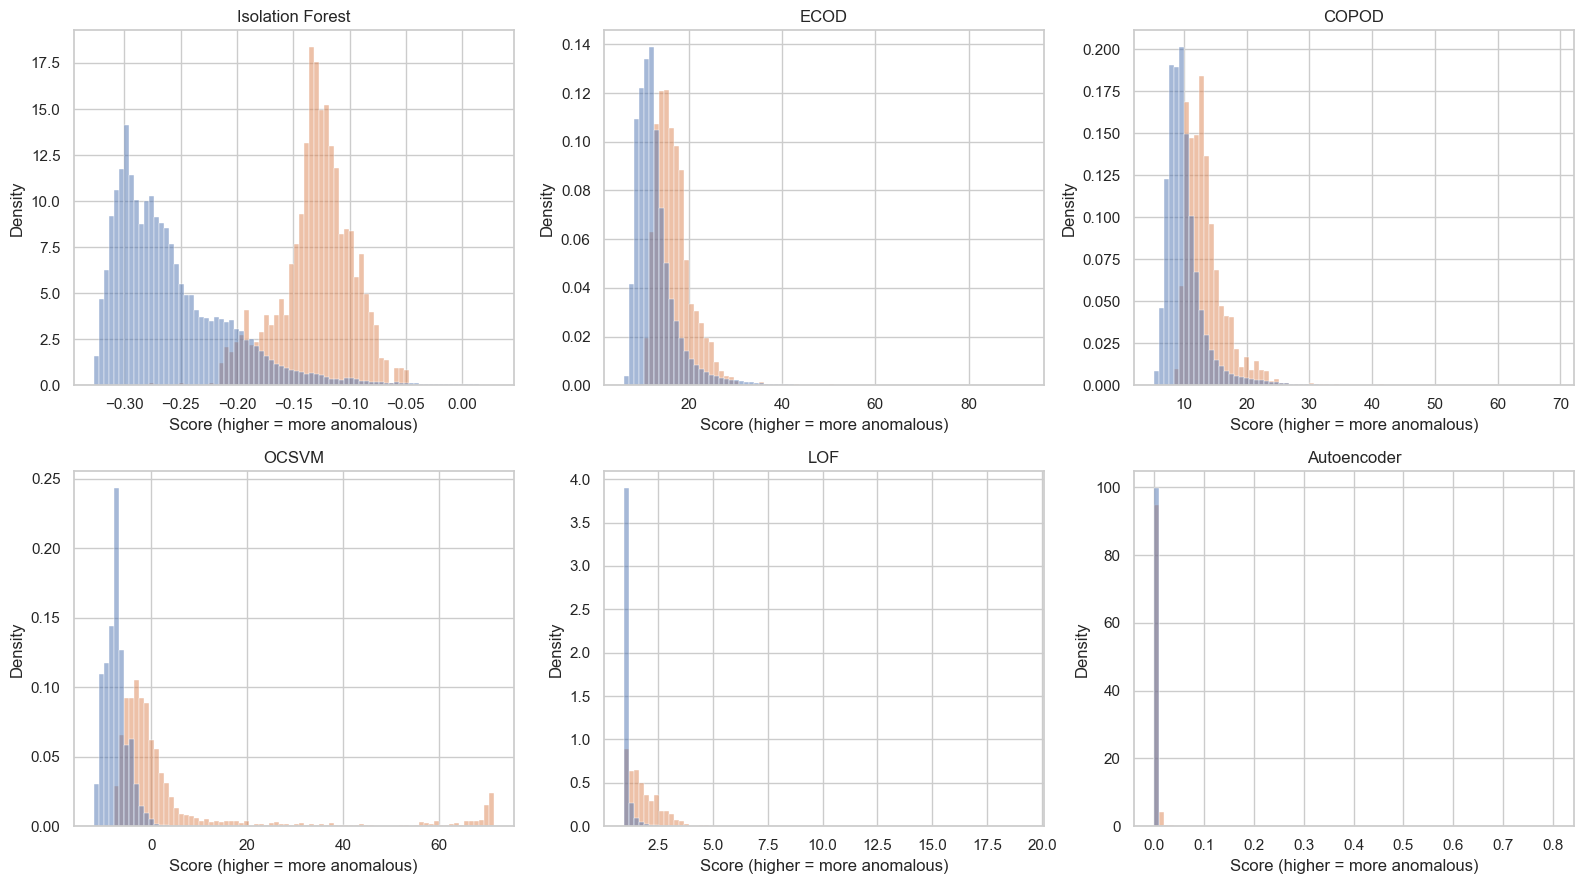

In [20]:
# Score distributions by class — visualises how cleanly each method
# separates fraud from legitimate activity. A useful detector produces
# distributions that are visibly shifted relative to each other; an
# unhelpful one produces distributions that overlap heavily.
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
score_pairs = [
    ("Isolation Forest", iforest_scores),
    ("ECOD",             ecod_scores),
    ("COPOD",            copod_scores),
    ("OCSVM",            ocsvm_scores),
    ("LOF",              lof_scores),
    ("Autoencoder",      ae_scores),
]
for ax, (name, scores) in zip(axes.flat, score_pairs):
    sns.histplot(
        x=scores, hue=y_test.values, bins=80, stat="density",
        common_norm=False, alpha=0.5, ax=ax, legend=False,
    )
    ax.set(title=name, xlabel="Score (higher = more anomalous)", ylabel="Density")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "anomaly_score_distributions.png", dpi=150)
plt.show()


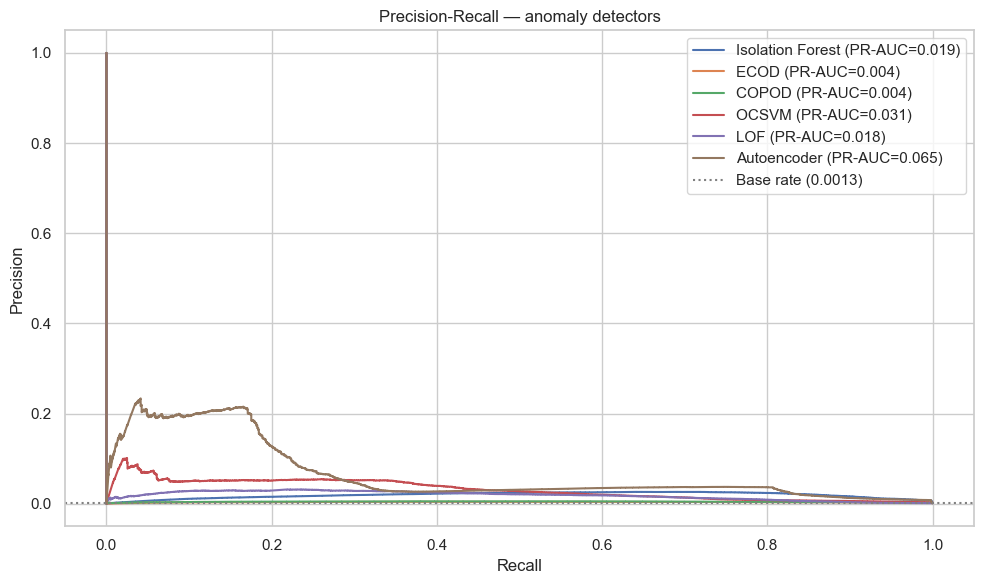

In [22]:
# Precision-recall curves — the operationally relevant view of detector
# quality under severe class imbalance.
fig, ax = plt.subplots(figsize=(10, 6))
for name, scores in score_pairs:
    precision, recall, _ = precision_recall_curve(y_test, scores)
    pr_auc = average_precision_score(y_test, scores)
    ax.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.3f})")
ax.axhline(y_test.mean(), linestyle=":", color="grey",
           label=f"Base rate ({y_test.mean():.4f})")
ax.set(title="Precision-Recall — anomaly detectors",
       xlabel="Recall", ylabel="Precision")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "anomaly_pr_curves.png", dpi=150)
plt.show()


## 11. Complexity table

The detection metrics above answer "which method works best". The table below answers "at what cost". For each method we report:

- **Train wall** — wall-clock time to fit, in seconds.
- **Score wall** — wall-clock time to score the test set, in seconds.
- **Peak memory** — peak Python-level memory during the fit (lower bound for methods that allocate inside C/C++ extensions).
- **Big-O train / score** — asymptotic complexity from the published literature.

The combination of detection performance and computational cost determines which method would actually be deployed.


In [23]:
def aggregate_repeats(prefix: str, suffix: str) -> float:
    """Mean of profile values across repeated runs sharing a prefix."""
    keys = [k for k in profile_results if k.startswith(prefix) and k.endswith(suffix)]
    if not keys:
        return float("nan")
    return float(np.mean([profile_results[k]["wall_seconds"] for k in keys]))


def aggregate_memory(prefix: str, suffix: str) -> float:
    keys = [k for k in profile_results if k.startswith(prefix) and k.endswith(suffix)]
    if not keys:
        return float("nan")
    return float(np.mean([profile_results[k]["peak_mb"] for k in keys]))


complexity = pd.DataFrame([
    {"Method": "Isolation Forest",
     "Train wall (s)": profile_results["iforest_fit"]["wall_seconds"],
     "Score wall (s)": profile_results["iforest_score"]["wall_seconds"],
     "Peak MB":        profile_results["iforest_fit"]["peak_mb"],
     "Train Big-O":    "O(t · ψ · log ψ)",
     "Score Big-O":    "O(t · log ψ) per row"},
    {"Method": "ECOD",
     "Train wall (s)": profile_results["ecod_fit"]["wall_seconds"],
     "Score wall (s)": profile_results["ecod_score"]["wall_seconds"],
     "Peak MB":        profile_results["ecod_fit"]["peak_mb"],
     "Train Big-O":    "O(n · d)",
     "Score Big-O":    "O(d) per row"},
    {"Method": "COPOD",
     "Train wall (s)": profile_results["copod_fit"]["wall_seconds"],
     "Score wall (s)": profile_results["copod_score"]["wall_seconds"],
     "Peak MB":        profile_results["copod_fit"]["peak_mb"],
     "Train Big-O":    "O(n · d)",
     "Score Big-O":    "O(d) per row"},
    {"Method": "OCSVM",
     "Train wall (s)": aggregate_repeats("ocsvm_fit", suffix=""),
     "Score wall (s)": aggregate_repeats("ocsvm_score", suffix=""),
     "Peak MB":        aggregate_memory("ocsvm_fit", suffix=""),
     "Train Big-O":    "O(n²) to O(n³)",
     "Score Big-O":    "O(SV · d) per row"},
    {"Method": "LOF",
     "Train wall (s)": aggregate_repeats("lof_fit", suffix=""),
     "Score wall (s)": aggregate_repeats("lof_score", suffix=""),
     "Peak MB":        aggregate_memory("lof_fit", suffix=""),
     "Train Big-O":    "O(n · k · d)",
     "Score Big-O":    "O(n_train · d) per row"},
    {"Method": "Autoencoder",
     "Train wall (s)": profile_results["autoencoder_fit"]["wall_seconds"],
     "Score wall (s)": profile_results["autoencoder_score"]["wall_seconds"],
     "Peak MB":        profile_results["autoencoder_fit"]["peak_mb"],
     "Train Big-O":    "O(epochs · n · d · h)",
     "Score Big-O":    "O(d · h) per row"},
])
complexity.round(2)


,Method,Train wall (s),Score wall (s),Peak MB,Train Big-O,Score Big-O
0,Isolation Forest,118.74,14.10,1891.74,O(t · ψ · log ψ),O(t · log ψ) per row
1,ECOD,15.92,18.11,3578.94,O(n · d),O(d) per row
2,COPOD,11.29,15.45,3578.85,O(n · d),O(d) per row
3,OCSVM,1.81,25.37,9.20,O(n²) to O(n³),O(SV · d) per row
4,LOF,0.59,12.06,56.37,O(n · k · d),O(n_train · d) per row
5,Autoencoder,154.41,82.20,895.29,O(epochs · n · d · h),O(d · h) per row


## 12. Reading the comparison

Three things to look for when reading the two tables together.

**Detection-vs-cost ranking.** The right-hand columns of the complexity table show which methods are operationally viable on the full data and which required subsampling. The PR-AUC ranking from the previous table shows which methods detect best. The product of the two rankings is the practical answer: a method that wins PR-AUC by a few percent at fifty times the cost may still be the wrong choice for a production system.

**Family effects.** PaySim's fraud signal sits at the boundary between two of the four anomaly families: it is partly a *deterministic accounting pattern* (which any density- or distribution-based method should pick up), and partly a *combination of categorical type and high amount* (which boundary-based or isolation methods should pick up). Comparing PR-AUC across families tells us which conceptual definition of "anomalous" best matches the simulator's notion of "fraudulent". This is informative beyond the numerical comparison: it says something about the structure of the dataset.

**Comparison to supervised baselines.** Whatever the best anomaly detector achieves on PR-AUC, it will sit below the supervised XGBoost (PR-AUC 0.98) and Random Forest (PR-AUC 1.00) from notebook 03. The gap is the price of not using labels at training time, and that price tells us how much "free" information the labels contain on this dataset. A small gap means the engineered features alone almost recover the labels; a large gap means supervised information is doing substantial work.

The honest framing for the thesis is: anomaly detection on PaySim is *not* a substitute for the supervised baseline. Its value is methodological, it shows what is detectable from the structure of legitimate activity alone, which is the property that matters for catching novel fraud patterns the labels do not contain. The supervised baseline maximises performance on known fraud; the anomaly detector maximises robustness to fraud-pattern drift. In notebook 05 the two are combined deliberately rather than treated as competitors.


## 13. Persisting the production-track models

Of the six methods evaluated, two are carried into the risk scoring framework: Isolation Forest as the lightweight detector for the operational stack (small memory footprint, sub-second scoring), and the autoencoder as a complementary reconstruction-based signal. ECOD and COPOD would be acceptable substitutes for IForest on grounds of stability, but IForest gives us a familiar interface and integrates with PyOD's downstream tooling.

OCSVM and LOF are not persisted: the subsampling required to fit them at scale makes them less attractive operationally, even when their detection metrics are competitive. The right deployment of these methods is on aggregated per-account or per-window summaries rather than on raw transactions, which is out of scope for this thesis.


In [24]:
joblib.dump(iforest, MODELS_DIR / "isolation_forest.pkl")
autoencoder.save(MODELS_DIR / "autoencoder.keras")

# Also save the score arrays so notebook 05 doesn't need to re-fit anything.
np.save(PROCESSED_DIR / "iforest_test_scores.npy", iforest_scores)
np.save(PROCESSED_DIR / "ae_test_scores.npy",      ae_scores)

print("Saved:")
print(f"  {MODELS_DIR / 'isolation_forest.pkl'}")
print(f"  {MODELS_DIR / 'autoencoder.keras'}")
print(f"  {PROCESSED_DIR / 'iforest_test_scores.npy'}")
print(f"  {PROCESSED_DIR / 'ae_test_scores.npy'}")


Saved:
  ..\src\models\isolation_forest.pkl
  ..\src\models\autoencoder.keras
  ..\data\processed\iforest_test_scores.npy
  ..\data\processed\ae_test_scores.npy


## 14. Limitations

**Subsampling variance.** The OCSVM and LOF results are means over three random seeds. Three is the smallest reasonable repeat count and the resulting standard deviations should be read as approximate. A more rigorous study would use ten or more seeds; we stop at three because the wall-clock cost of each repeat is non-trivial and the standard deviations are already small enough to support the qualitative conclusions.

**Hyperparameters.** All methods use either default hyperparameters or values from the published literature. Bayesian optimisation against PR-AUC would close some of the gap between methods but would also tune toward the test set unless done on a held-out validation split. We do not tune in this notebook because the comparison is methodological — different families of anomaly detection — rather than performance-maximising for any single method.

**Aggregation feature space.** All six methods score raw transactions independently. A real fraud detection system also operates on aggregated features computed over windows of activity per account: rolling counts, amount sums, recipient-overlap statistics. Anomaly detectors on these aggregates often outperform the same methods on raw transactions because behavioural anomalies are inherently temporal. PaySim's `step` resolution and the random train/test split make this hard to do honestly, so we leave it out and flag it as the most important methodological extension for real-data work.

**Synthetic data.** Every caveat from notebook 03 about PaySim's deterministic balance pattern applies here too. The methods that perform well on this dataset are the ones whose anomaly definition aligns with the simulator's fraud-generation rule. A different synthetic generator with different rules would produce a different ranking, and real fraud — which does not follow a single deterministic rule — would shift the ranking again.
